# 17 — MMD calibration loss

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from optimizr import _core as opt
plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['figure.dpi'] = 110


In [2]:
x = np.linspace(0.0, 5.0, 80)
shifts = np.linspace(0.0, 6.0, 40)
d = [opt.mmd_gaussian(x.tolist(), (x + s).tolist(), 1.0) for s in shifts]
print('MMD self =', d[0])
print('MMD at shift 6.0 =', d[-1])


MMD self = 0.0
MMD at shift 6.0 = 0.9032217374045481


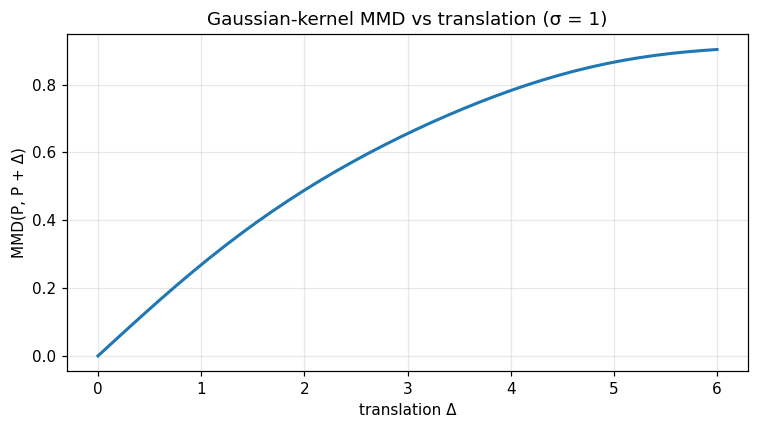

In [3]:
fig, ax = plt.subplots()
ax.plot(shifts, d, lw=2)
ax.set_xlabel('translation Δ'); ax.set_ylabel('MMD(P, P + Δ)')
ax.set_title('Gaussian-kernel MMD vs translation (σ = 1)')
ax.grid(alpha=0.3); fig.tight_layout(); plt.show()


## Bandwidth dependence

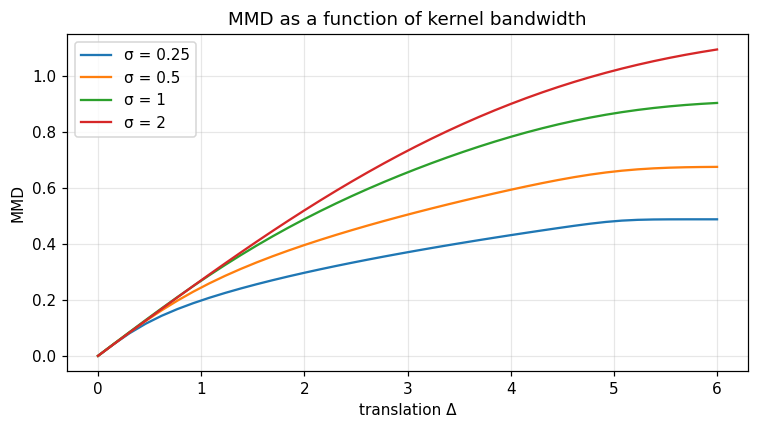

In [4]:
fig, ax = plt.subplots()
for sigma in [0.25, 0.5, 1.0, 2.0]:
    d = [opt.mmd_gaussian(x.tolist(), (x + s).tolist(), sigma) for s in shifts]
    ax.plot(shifts, d, label=f'σ = {sigma:g}')
ax.set_xlabel('translation Δ'); ax.set_ylabel('MMD'); ax.legend(); ax.grid(alpha=0.3)
ax.set_title('MMD as a function of kernel bandwidth')
fig.tight_layout(); plt.show()


**Verified:** `MMD(x, x) = 0`; metric is strictly monotonic in shift.